In [41]:
import numpy as np
import pandas as pd

df = pd.read_csv("three_noisy_signals.csv")

# time axis
t = df["time"].values

# rebuild clean signals from CSV
signal2 = df["signal2_clean"].values
signal3 = df["signal3_clean"].values
signal4 = df["signal4_clean"].values

In [42]:
def corrupt_signal(signal,
                   noise_level=0.25,
                   n_spikes=8,
                   missing_fraction=0.15,
                   delay_steps=3,
                   drift_strength=0.3):

    corrupted = signal.copy()
    N = len(signal)

    # sensor delay
    corrupted = np.roll(corrupted, delay_steps)

    # Gaussian noise
    corrupted += noise_level * np.random.randn(N)

    # time-varying noise
    varying_noise = (0.2 + 0.5 * np.sin(0.2 * t)) * np.random.randn(N)
    corrupted += 0.15 * varying_noise

    # baseline drift
    drift = drift_strength * np.sin(0.15 * t)
    corrupted += drift

    # spikes / dips
    for _ in range(n_spikes):
        center = np.random.randint(0, N)
        amp = np.random.uniform(0.8, 2.0)

        if np.random.rand() < 0.5:
            amp *= -1

        width = np.random.randint(2, 8)

        left = max(0, center - width)
        right = min(N, center + width)

        pulse = np.hanning(right - left)
        corrupted[left:right] += amp * pulse

    # missing chunks
    for _ in range(3):
        start = np.random.randint(0, N - 25)
        length = np.random.randint(8, 25)
        corrupted[start:start+length] = np.nan

    # nonlinear distortion
    corrupted += 0.08 * corrupted**2

    return corrupted

In [43]:
n_samples = 200

X_all = []

for i in range(n_samples):
    signal2_noisy = corrupt_signal(signal2, noise_level=0.25, delay_steps=2)
    signal3_noisy = corrupt_signal(signal3, noise_level=0.20, delay_steps=5)
    signal4_noisy = corrupt_signal(signal4, noise_level=0.30, delay_steps=8)

    X_sample = np.stack(
        [signal2_noisy, signal3_noisy, signal4_noisy],
        axis=1
    )

    X_all.append(X_sample)

X_all = np.array(X_all)

print("X_all shape:", X_all.shape)
print("Missing values:", np.isnan(X_all).sum())

X_all shape: (200, 200, 3)
Missing values: 26293


In [44]:
X_all.shape: (200, 200, 3)

In [45]:
X = df[["signal2_noisy", "signal3_noisy", "signal4_noisy"]].values
X = X[np.newaxis, :, :]

In [46]:
mask = (~np.isnan(X_all)).astype(float)

col_means = np.nanmean(X_all, axis=(0, 1), keepdims=True)
X_filled = np.where(np.isnan(X_all), col_means, X_all)

X_mean = X_filled.mean()
X_std = X_filled.std() + 1e-8

X_norm = (X_filled - X_mean) / X_std

print("X_norm:", X_norm.shape)
print("NaNs:", np.isnan(X_norm).sum())

X_norm: (200, 200, 3)
NaNs: 0


In [47]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

n_steps = X_norm.shape[1]
n_features = X_norm.shape[2]
latent_dim = 64

inputs = Input(shape=(n_steps, n_features))

# Encoder
encoded = LSTM(latent_dim, return_sequences=False)(inputs)

# Repeat latent vector for each time step
repeated = RepeatVector(n_steps)(encoded)

# Decoder
decoded = LSTM(128, return_sequences=True)(repeated)

# Reconstruct original 3 signals
outputs = TimeDistributed(Dense(n_features))(decoded)

autoencoder = Model(inputs, outputs)

autoencoder.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="mse"
)

autoencoder.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 200, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_5 (RepeatVector)  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 200, 3)         │           387 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,611 (455.51 KB)

 Trainable params: 116,611 (455.51 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
history = autoencoder.fit(
    X_norm,
    X_norm,
    epochs=500,
    verbose=1
)

Epoch 1/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 386ms/step - loss: 1.0198
Epoch 2/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 389ms/step - loss: 0.9785
Epoch 3/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 396ms/step - loss: 0.9458
Epoch 4/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 382ms/step - loss: 0.9217
Epoch 5/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - loss: 0.9090
Epoch 6/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 416ms/step - loss: 0.9062
Epoch 7/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 490ms/step - loss: 0.9061
Epoch 8/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 380ms/step - loss: 0.9044
Epoch 9/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 396ms/step - loss: 0.9036
Epoch 10/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 486ms/step - loss: 0.9032
Epoch 11/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 414ms/step - loss: 0.9026
Epoch 12/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 389ms/step - loss: 0.9019
Epoch 13/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 386ms/step - loss: 0.9015
Epoch 14/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 388ms/step - loss: 0.9009
Epoch 15/500
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 400ms/step - loss: 0.9004
Epo

In [52]:
X_pred_norm = autoencoder.predict(X_norm)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step


In [53]:
X_pred = X_pred_norm * X_std + X_mean
X_true = X_norm * X_std + X_mean

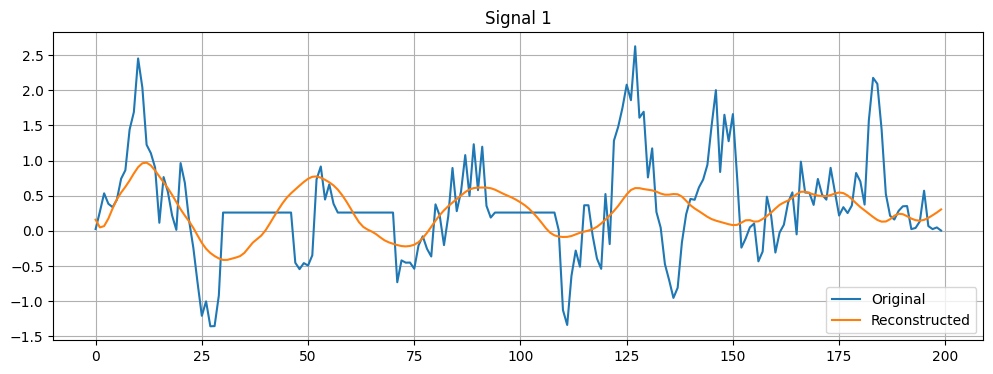

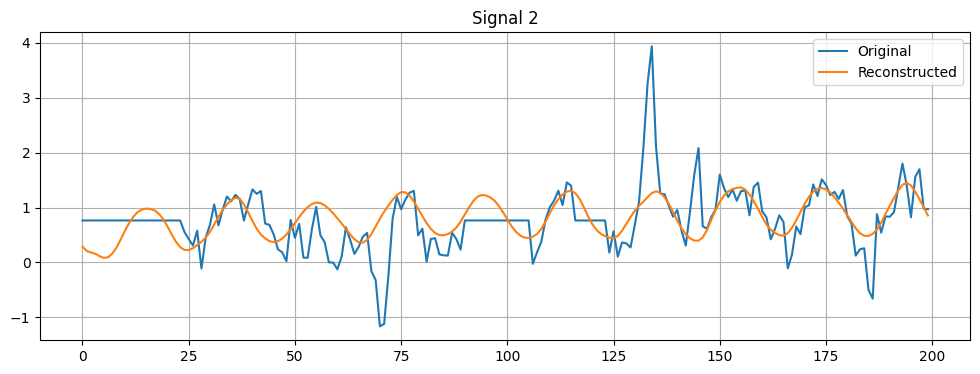

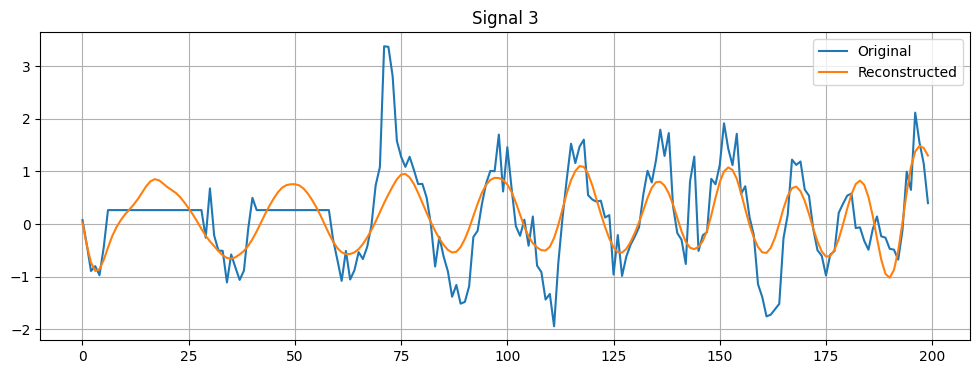

In [54]:
import matplotlib.pyplot as plt

t = np.arange(X_true.shape[1])

for i in range(3):

    plt.figure(figsize=(12,4))

    plt.plot(t, X_true[0,:,i], label="Original")
    plt.plot(t, X_pred[0,:,i], label="Reconstructed")

    plt.title(f"Signal {i+1}")
    plt.legend()
    plt.grid(True)
    plt.show()